# Process Igneous Zircon U-Pb Data
This notebook processes igneous zircon U-Pb data from Arizona LaserChron Center into a format that can be used by subsequent notebooks

In [21]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt

import cmcrameri.cm as cmc

from geoscripts.dz import dz,mda

from matplotlib import rc
rc("pdf", fonttype=42)

In [22]:
# Write function to process Laserchron Excel files
def extract_lchron_ig(name, path):

    accepted = pd.read_excel(path,skiprows=22,header=None,index_col=0,usecols='A:T')
    cols_combined = accepted.iloc[0] + ' ' + accepted.iloc[1]
    accepted.columns = cols_combined
    accepted.drop(accepted.index[:3],inplace=True)

    rejected = pd.read_excel(path,skiprows=22,header=None,index_col=0,usecols='W:AP')
    rejected.columns = cols_combined
    rejected.drop(rejected.index[:3],inplace=True)
    
    # Extract spots using name with a missing zero
    name_missingzero = name[:5] + name[6:]
    accepted = accepted[accepted.index.str.startswith(name_missingzero)]
    rejected = rejected[rejected.index.str.startswith(name_missingzero)]
    
    return(accepted,rejected,name)

In [23]:
# Extract data from Laserchron files
directory = './laserchron_data'
files = os.listdir(directory)
paths = [os.path.join(directory,file) for file in files if (file.startswith('Van')
         & file.endswith('.xlsx'))]

names = ['MR24-010','MR24-012','MR24-013','MR24-015','MR24-016']
names_missingzero = [name[:5] + name[6:] for name in names]
paths_mapped = [next(path for path in paths if name in path) for name in names_missingzero]

data = [extract_lchron_ig(name, path) for name, path in zip(names, paths_mapped)]

# Print columns
print(data[0][0].columns)

Index(['U (ppm)', '206Pb 204Pb', 'U/Th  ', '206Pb* 207Pb*', '± 2s (%)',
       '207Pb* 235U', '± 2s (%)', '206Pb* 238U', '± 2s (%)', 'error corr.',
       '206Pb* 238U', '± 2s (Ma)', '207Pb* 235U', '± 2s (Ma)', '206Pb* 207Pb*',
       '± 2s (Ma)', 'Best age (Ma)', '± 2s (Ma)', 'Conc (%)'],
      dtype='object')


In [24]:
# Get location data from field notes
meta_mr = pd.read_csv('field_data/2024_mr_field_samples.csv',index_col=0)
locations = meta_mr[['Latitude','Longitude']]

/home/dyvasey/git/geoscripts/geoscripts/dz/dz.py:628: RuntimeWarning: invalid value encountered in scalar divide
  self.mda_mswd = squares_summed/deg_free


Propagating systematic error -  0.8 
Original error:  3.4
6
Propagating systematic error -  0.8 
Original error:  1.5200698324970618
49
Propagating systematic error -  0.8 
Original error:  1.4509820883983724
48
Propagating systematic error -  0.8 
Original error:  4.089675099211381
39
Propagating systematic error -  0.8 
Original error:  1.4131910276521145
45


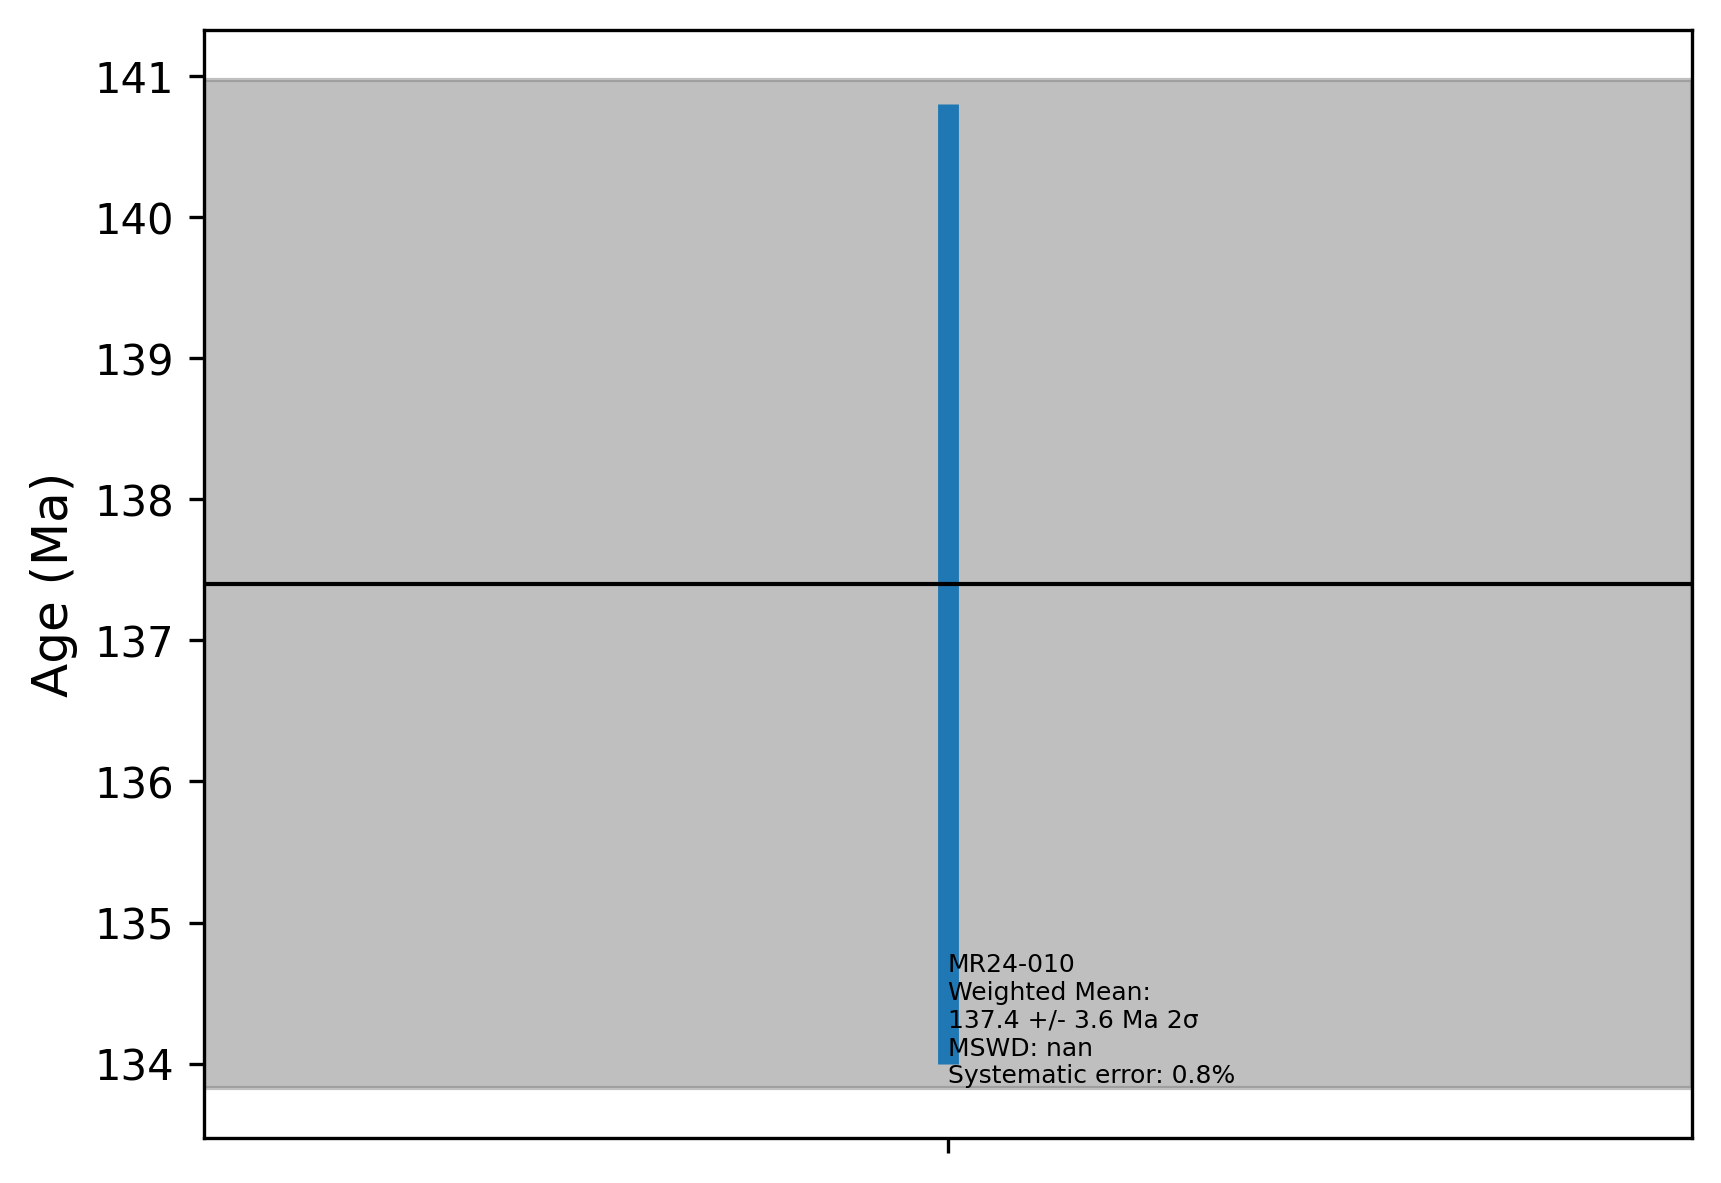

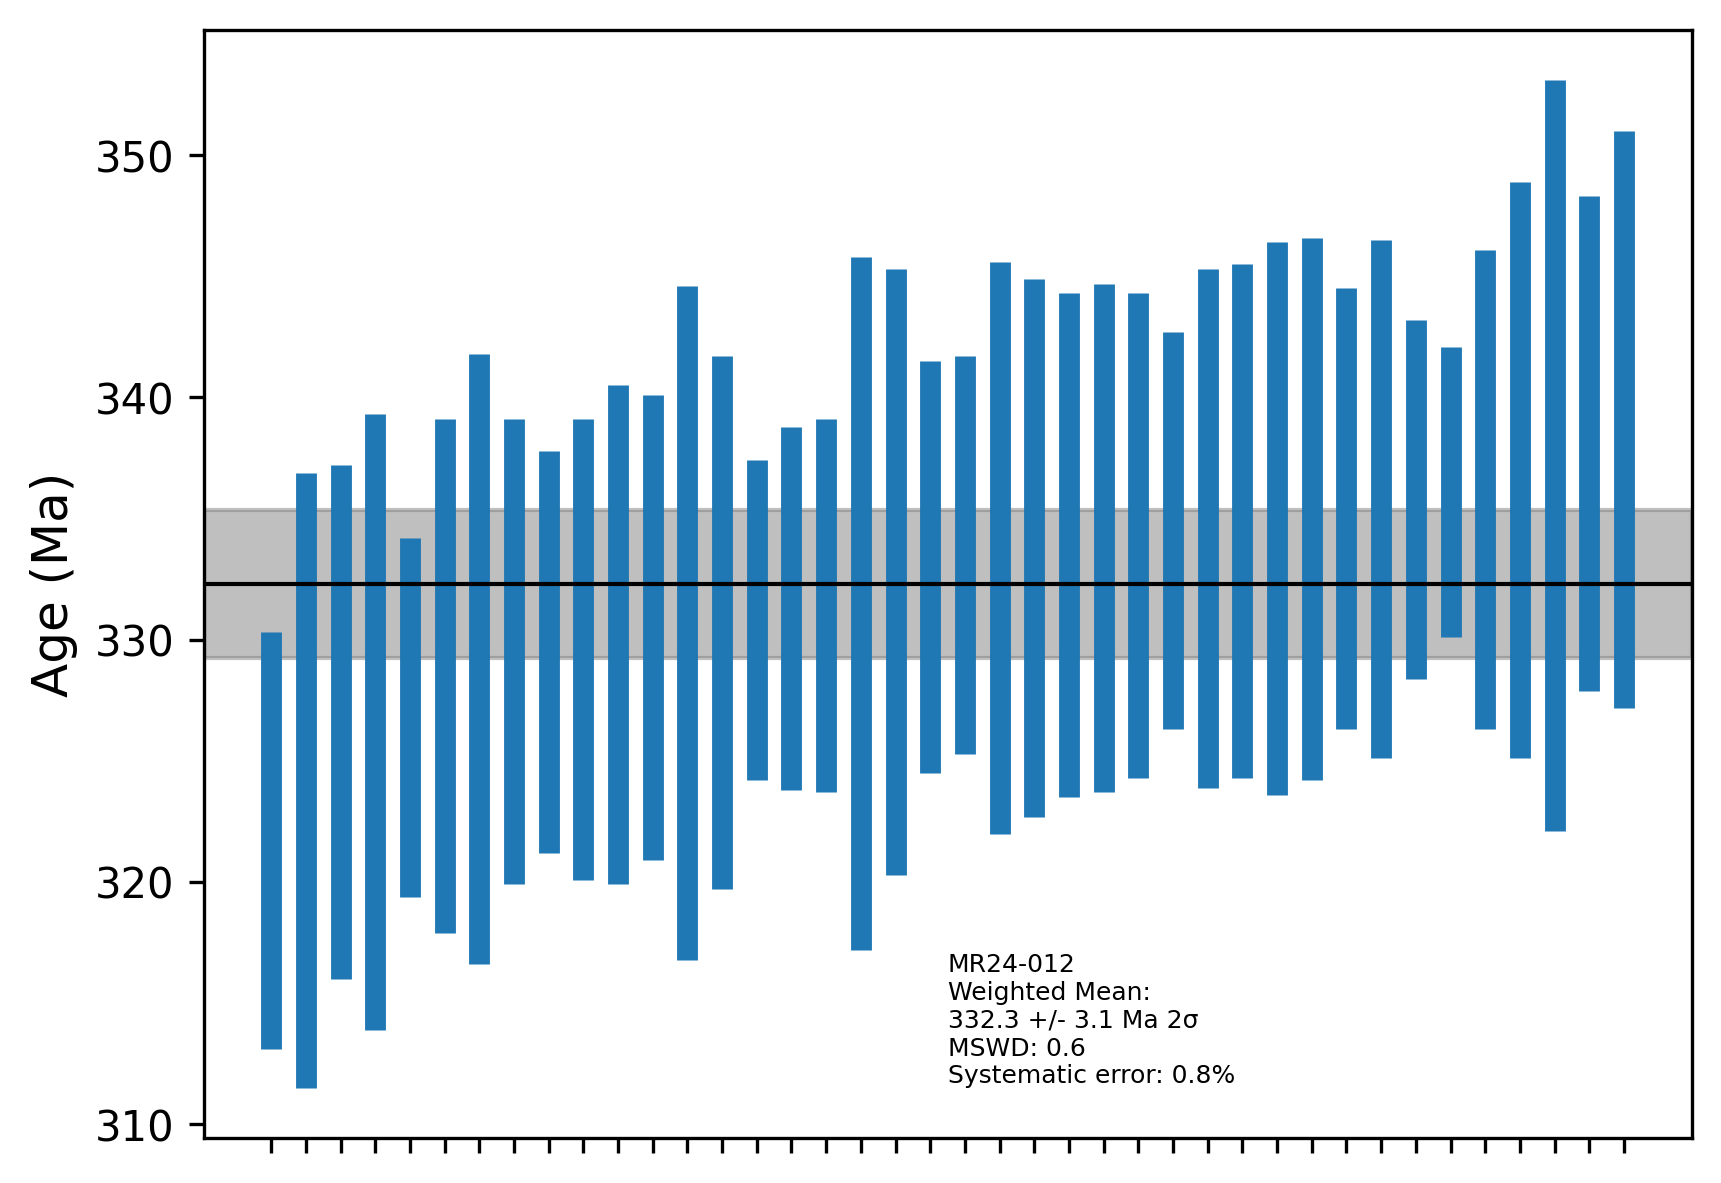

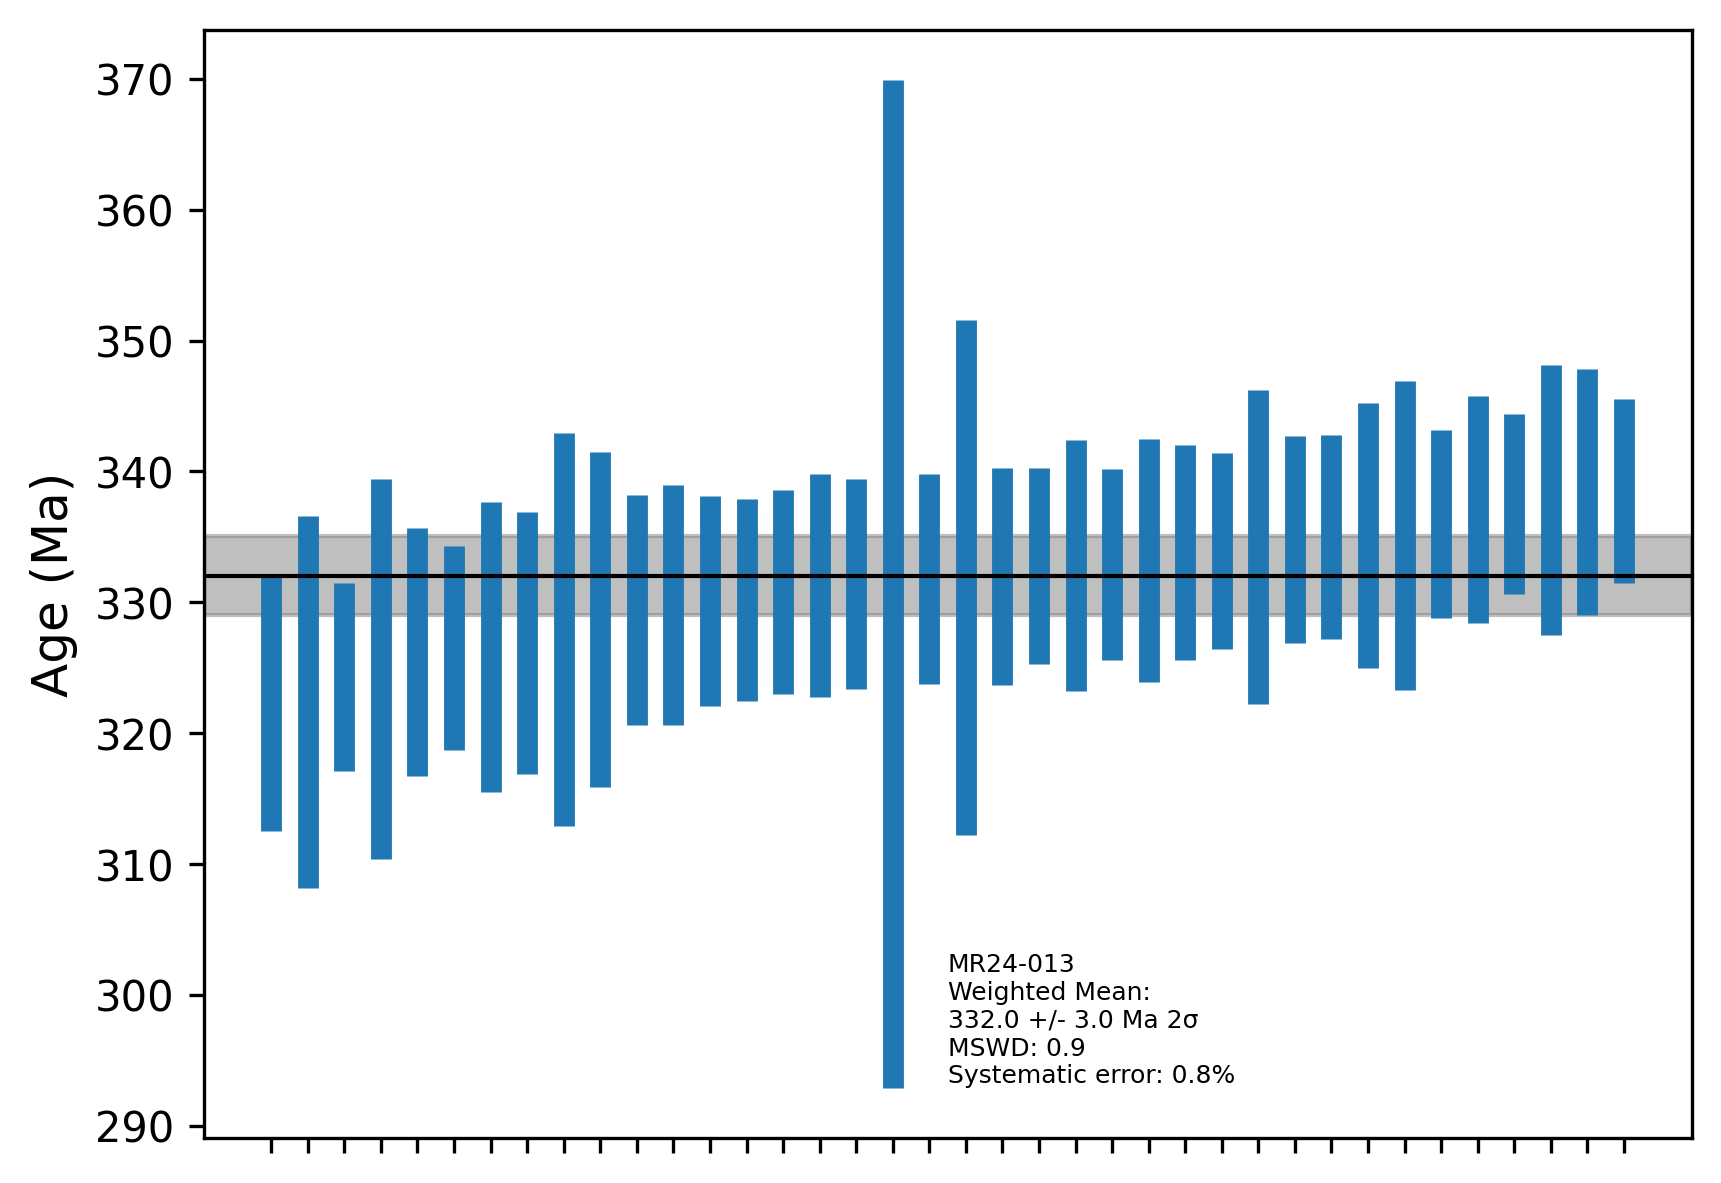

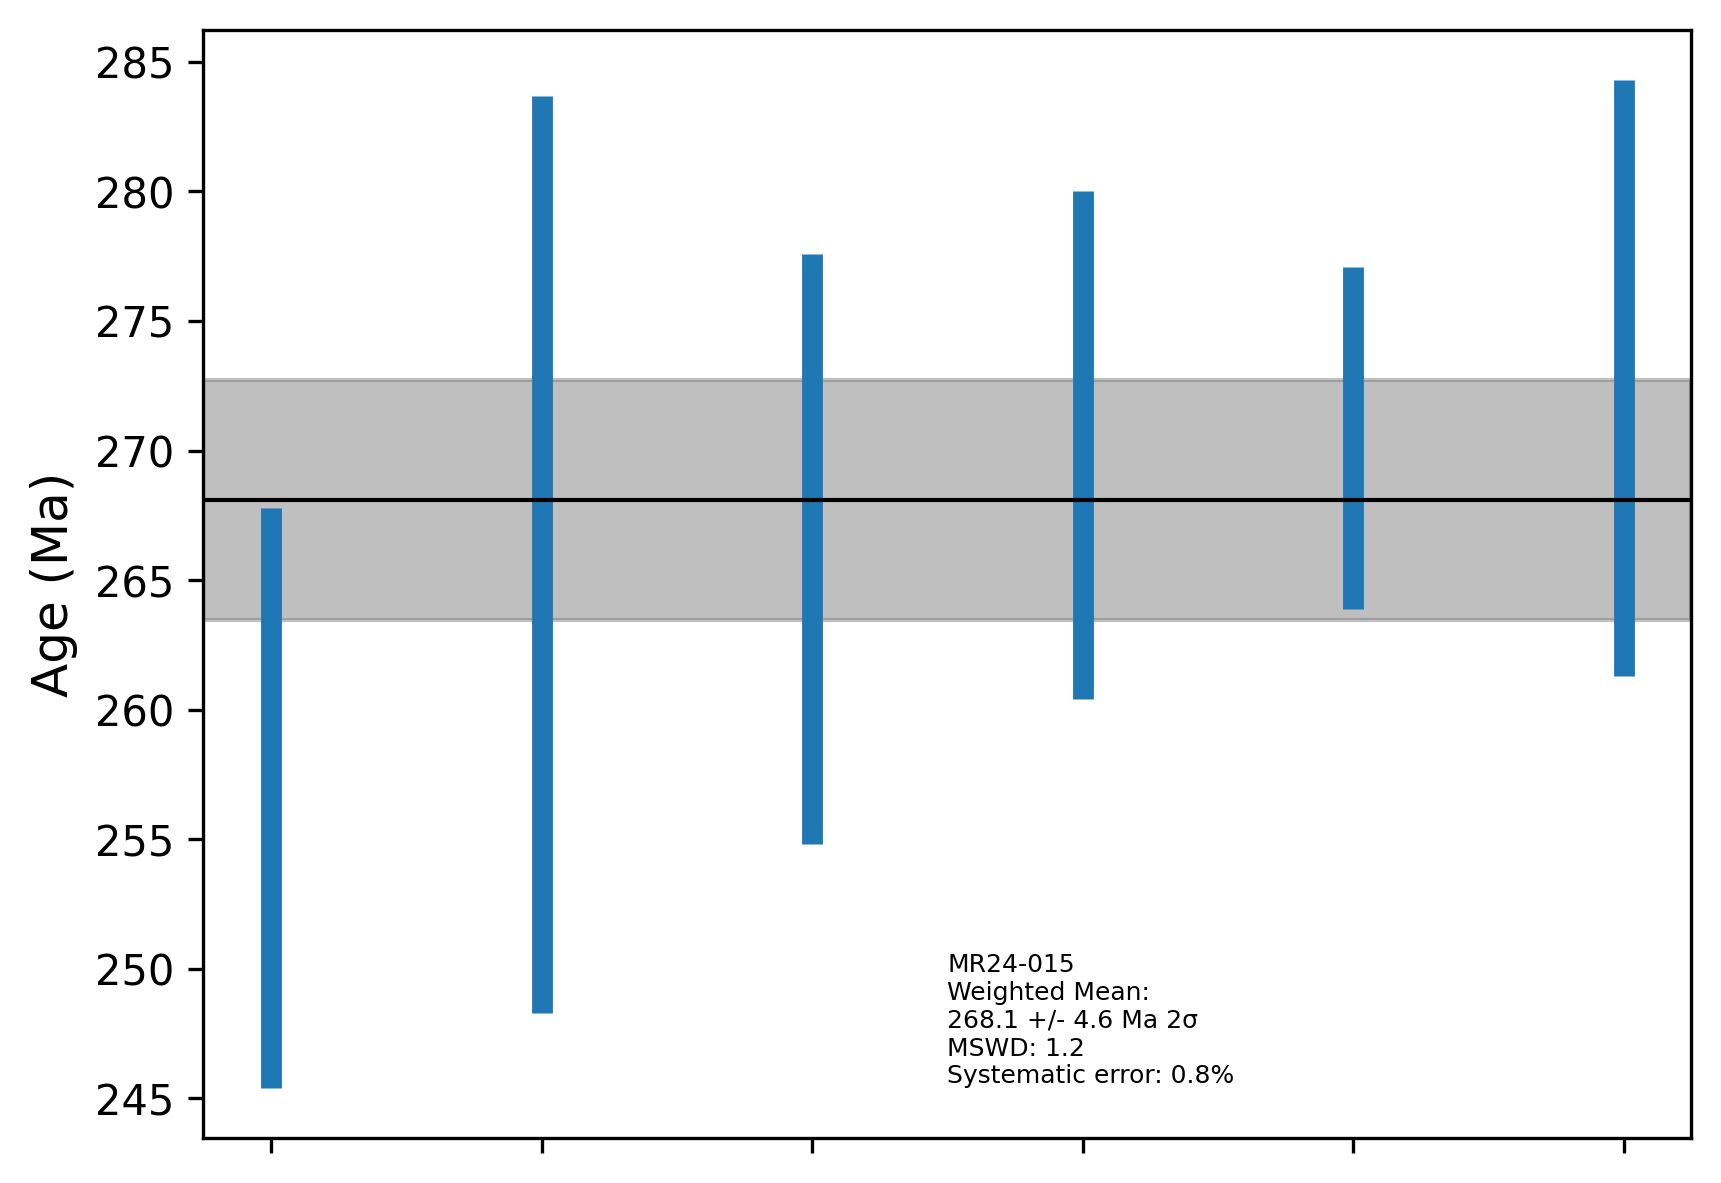

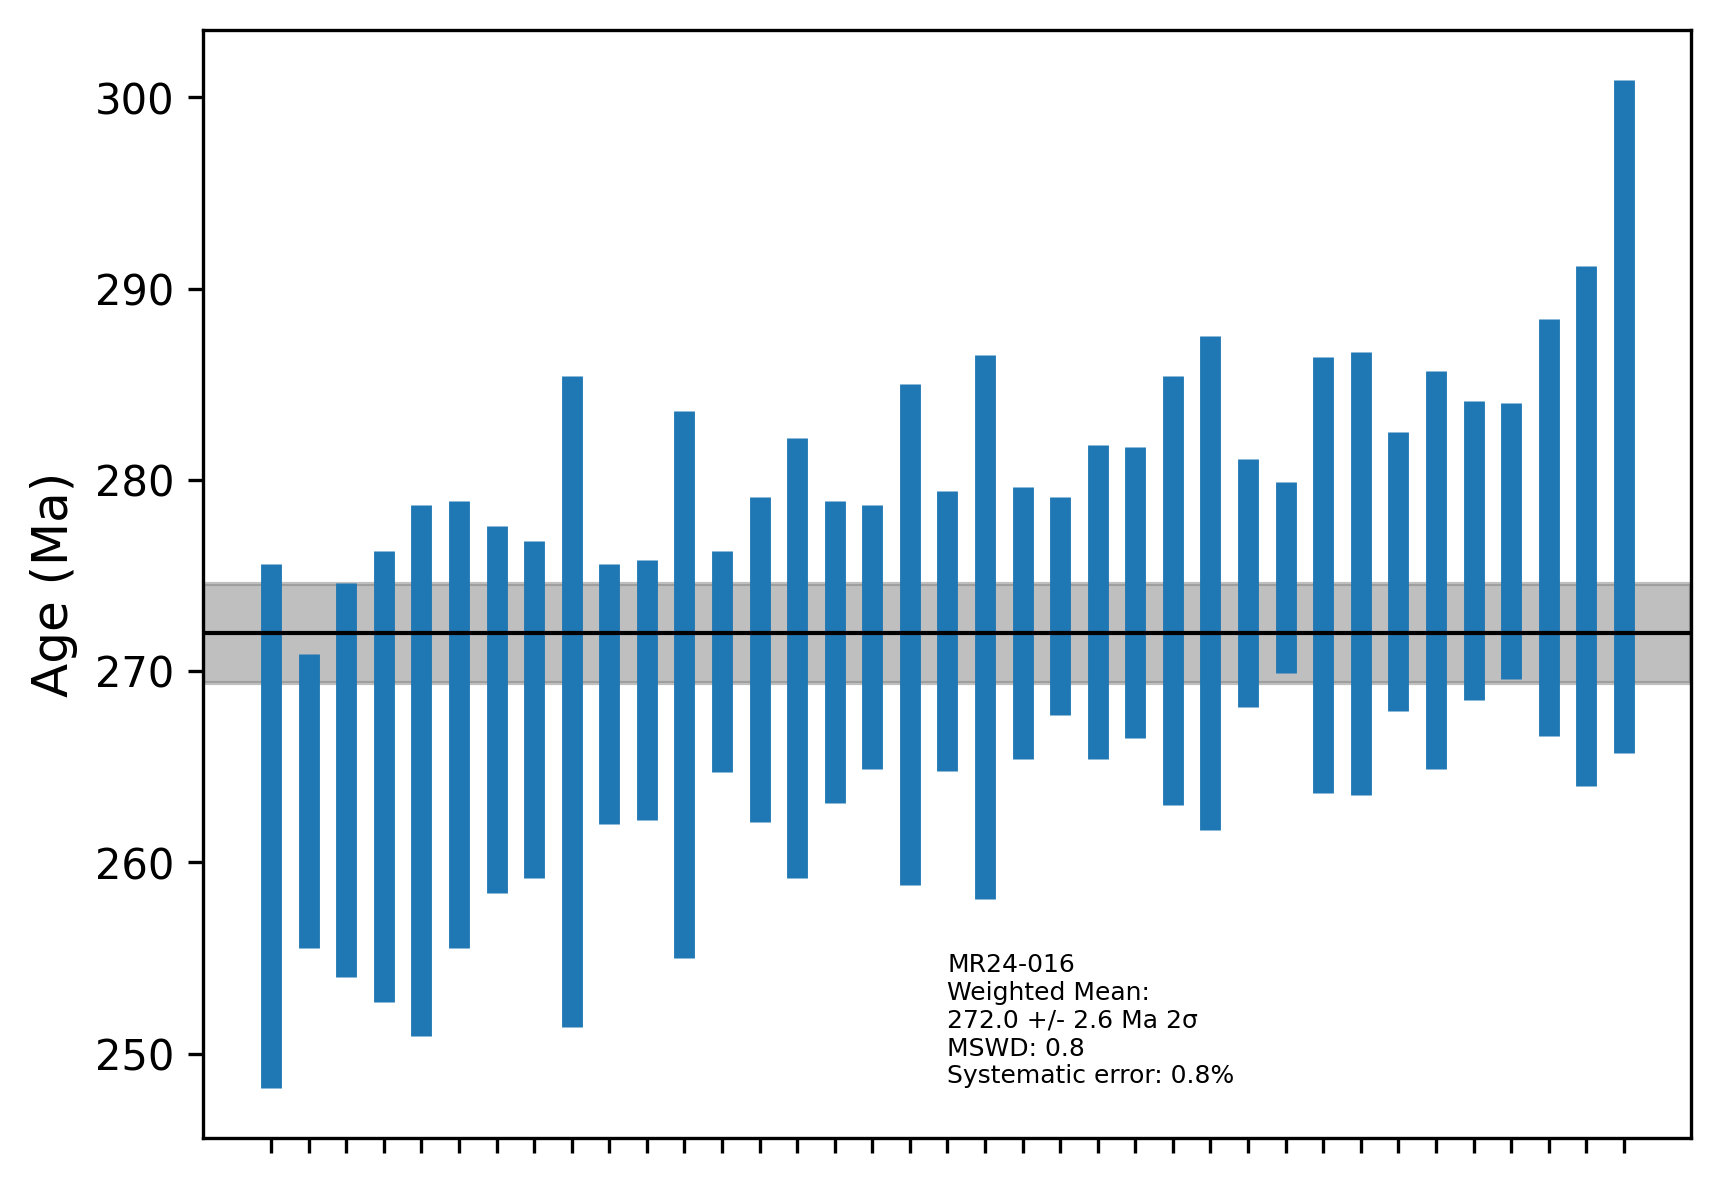

In [30]:
# Create DZ objects from data
smps = [dz.DZSample(name=sample[2],agedata=sample[0],
                    latlon=(locations.loc[sample[2],'Latitude'],
                            locations.loc[sample[2],'Longitude']),
                            source='VanTongeren',reported_age='Pz') for sample in data]
smps.sort(key=lambda x: x.name)

for smp in smps:
    smp.bestage = smp.agedata['Best age (Ma)'].astype(float)
    smp.bestage.name = 'Best Age'
    smp.besterror = smp.agedata.iloc[:,-2].astype(float)
    smp.besterror.name = '2sig'
    smp.error_level = '2sig'
    smp.syst_238=0.8

    if smp.name=='MR24-010':
        smp.calc_mda(method='manual',grains=[0],systematic=True)

    else:
        smp.calc_mda(systematic=True)

    print(len(smp.bestage))
    smp.save()

Propagating systematic error -  0.8 
Original error:  4.0
Propagating systematic error -  0.8 
Original error:  3.4


/home/dyvasey/git/geoscripts/geoscripts/dz/dz.py:628: RuntimeWarning: invalid value encountered in scalar divide
  self.mda_mswd = squares_summed/deg_free
/home/dyvasey/git/geoscripts/geoscripts/dz/dz.py:628: RuntimeWarning: invalid value encountered in scalar divide
  self.mda_mswd = squares_summed/deg_free


(137.4,
 3.573267501881156,
 0    137.4
 Name: Best Age, dtype: float64,
 0    3.4
 Name: 2sig, dtype: float64)

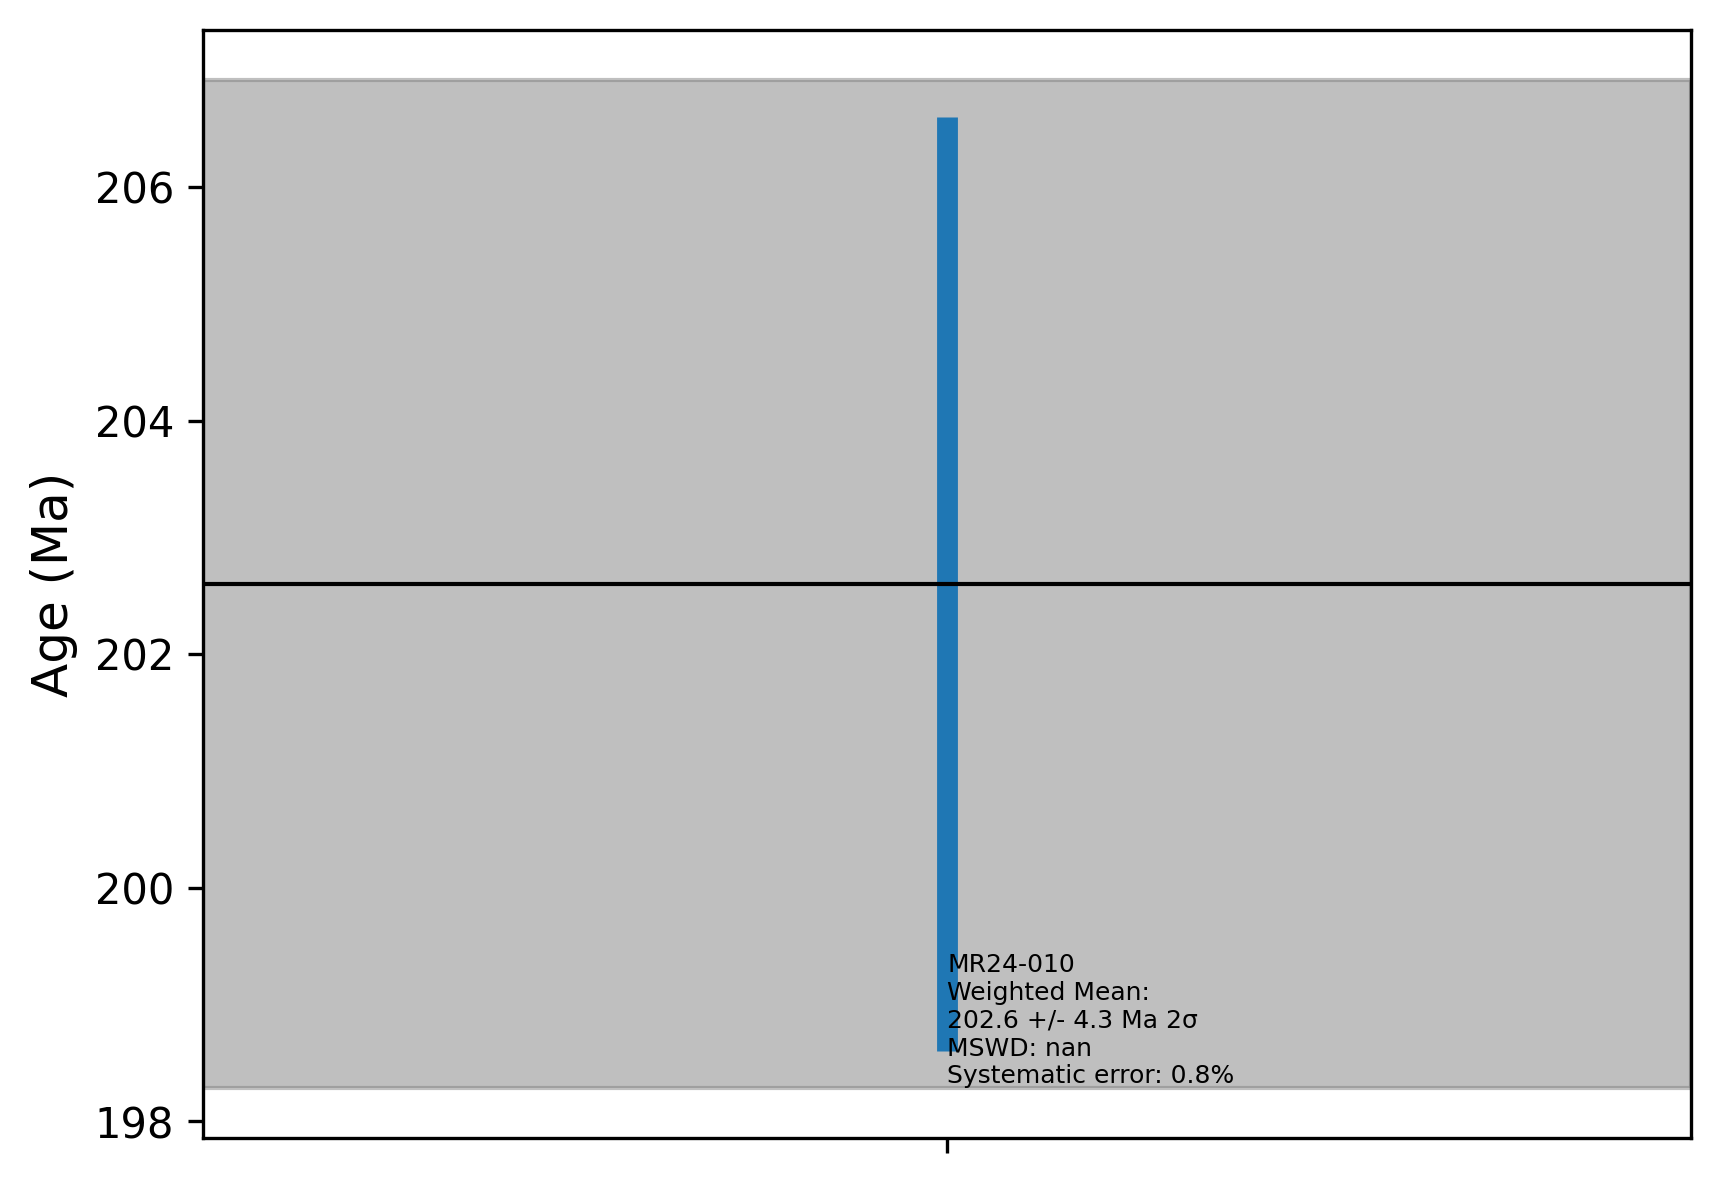

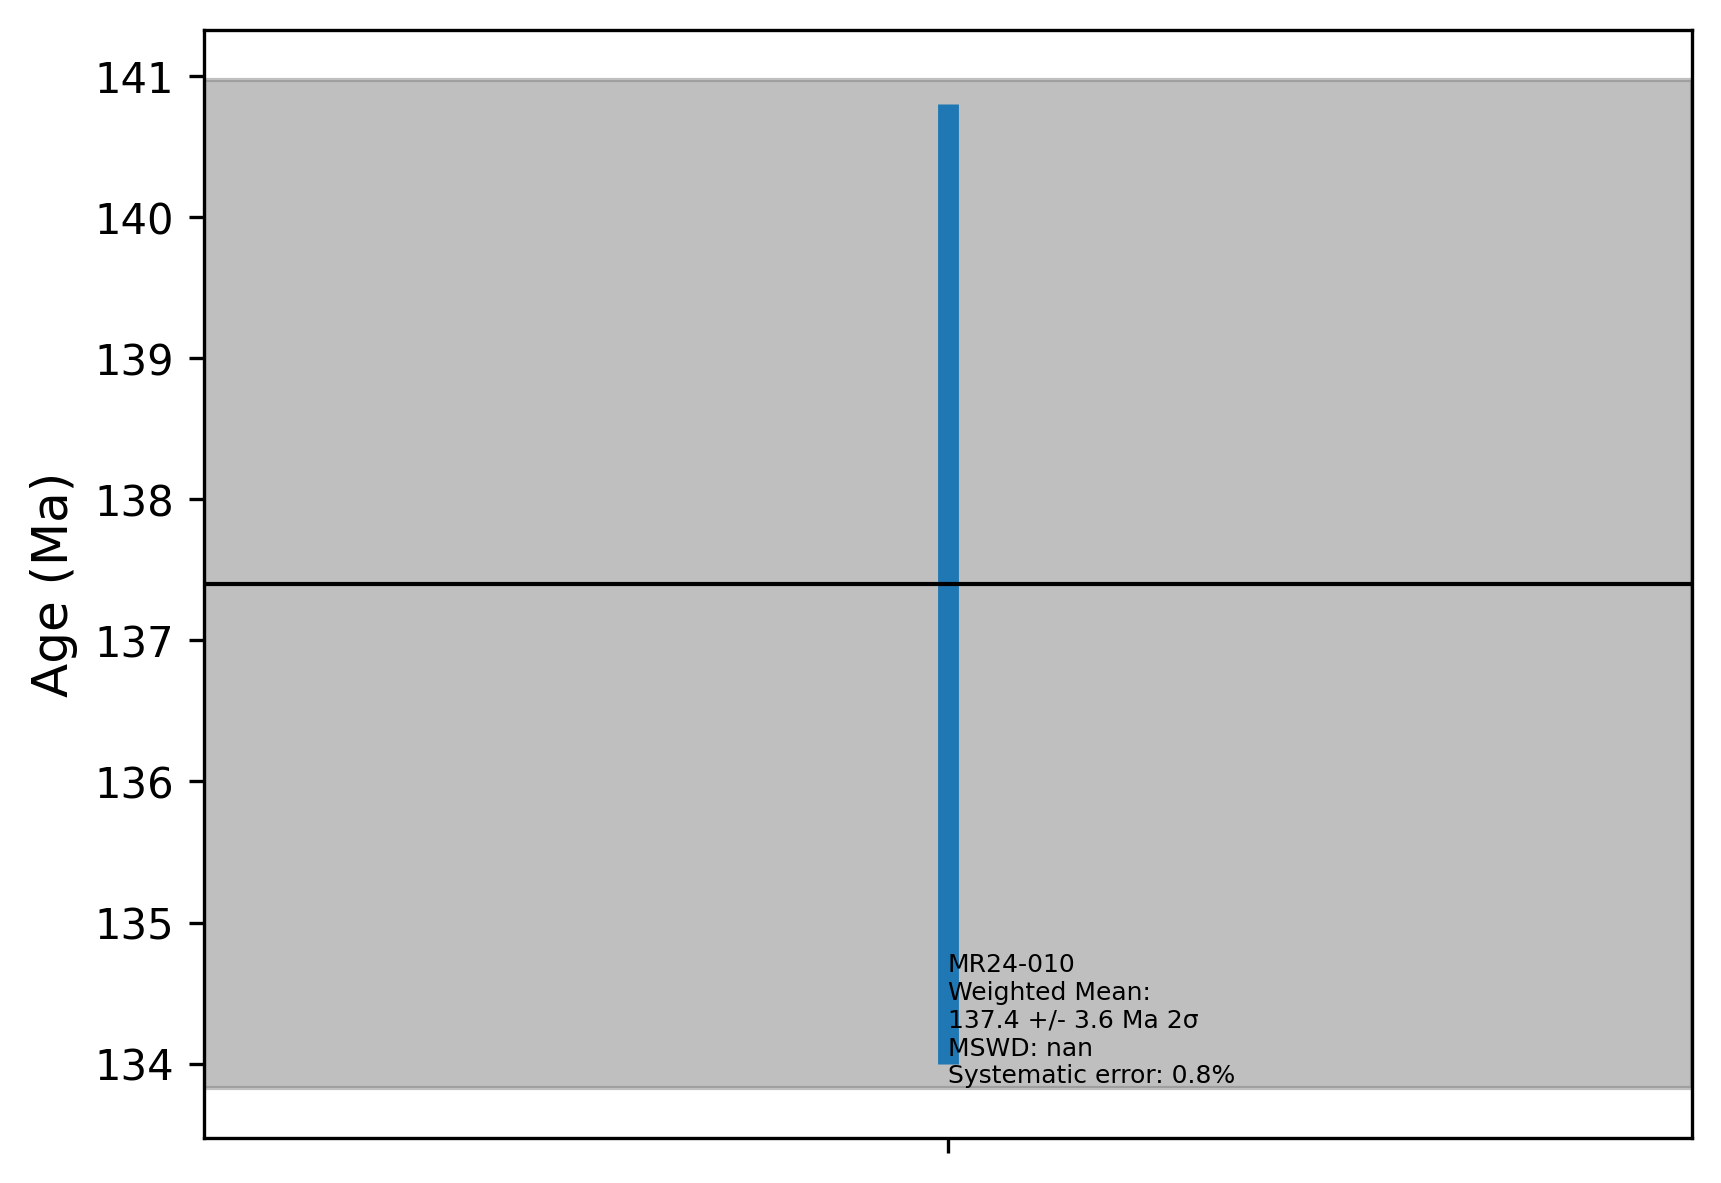

In [26]:
# Redo MR24-010 to get full uncertainty for second-oldest grain
smp = [smp for smp in smps if smp.name=='MR24-010'][0]
smp.calc_mda(method='manual',grains=[1],systematic=True)

smp.calc_mda(method='manual',grains=[0],systematic=True)

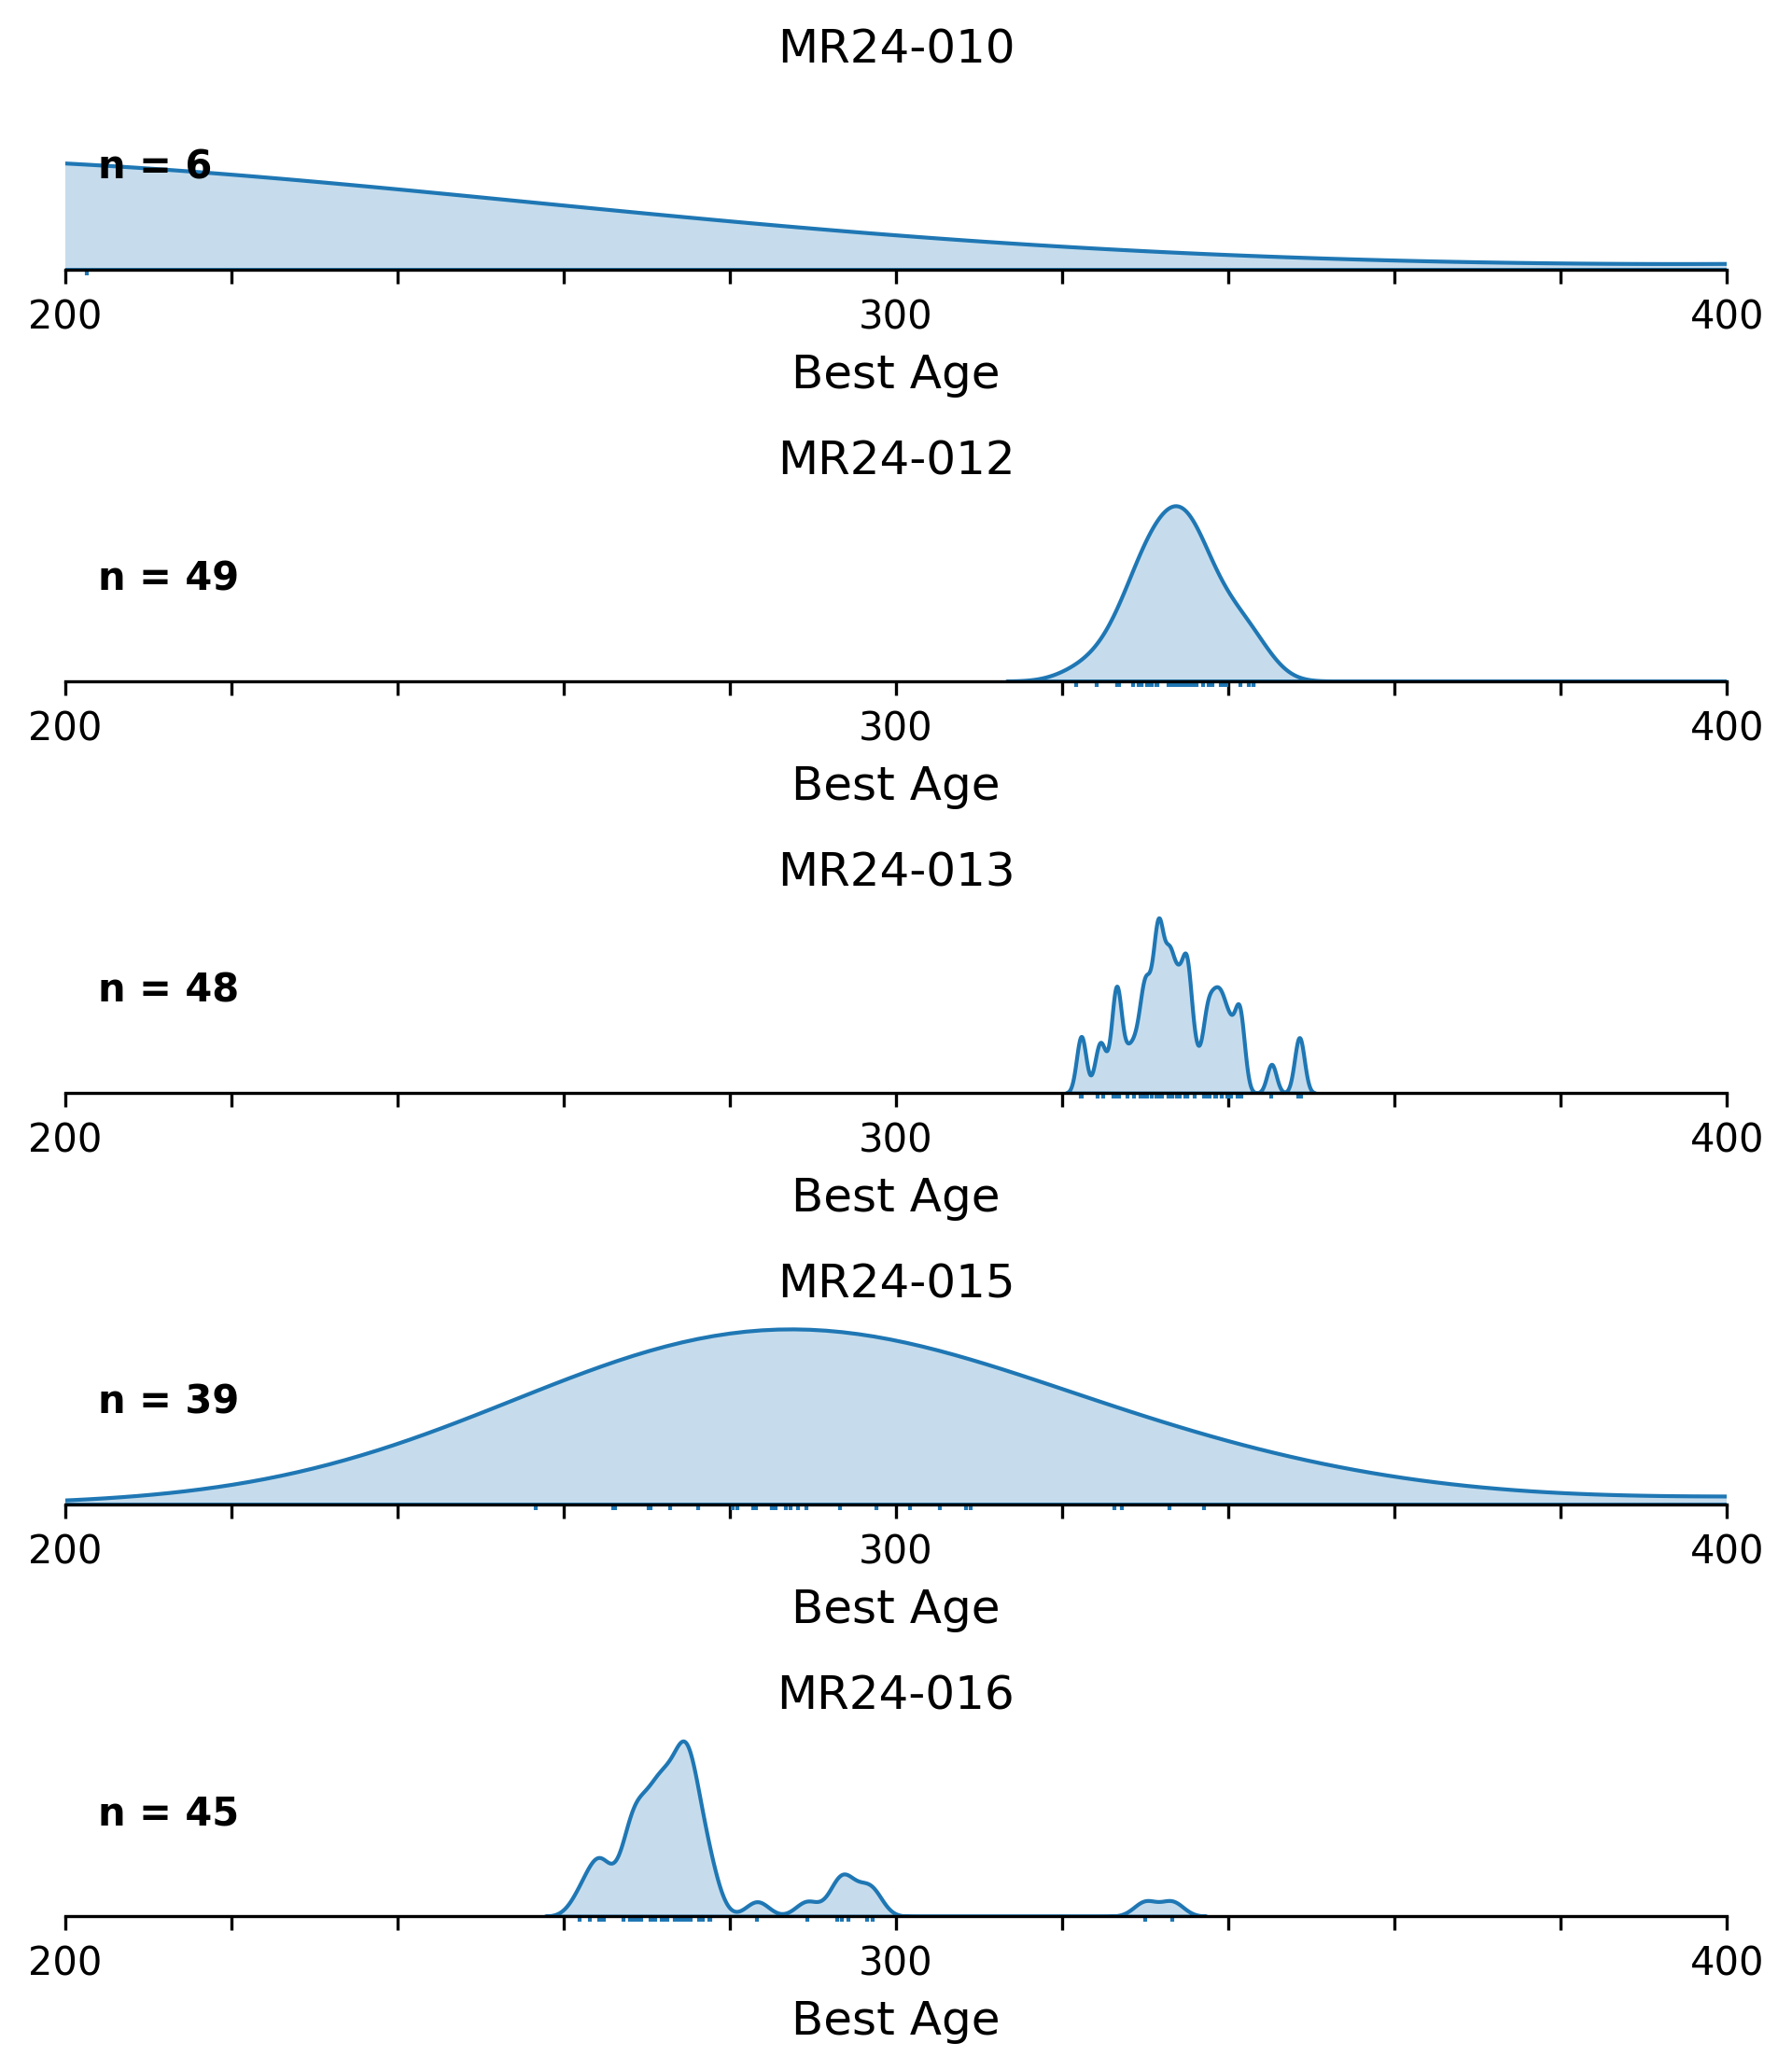

In [27]:
# Plot KDEs using existing best ages (not calculated)
fig,axs = plt.subplots(len(smps),figsize=(6.5,1.5*len(smps)),dpi=300)

for k,smp in enumerate(smps):
    ax = axs[k]
    smp.kde(ax=ax,bw_adjust=0.2,log_scale=False)
    ax.set_xlim(200,400)
    ax.set_title(smp.name)
    ax.set_xticks(np.arange(200,401,20))

plt.tight_layout()
fig.savefig('kdes_ig.pdf')

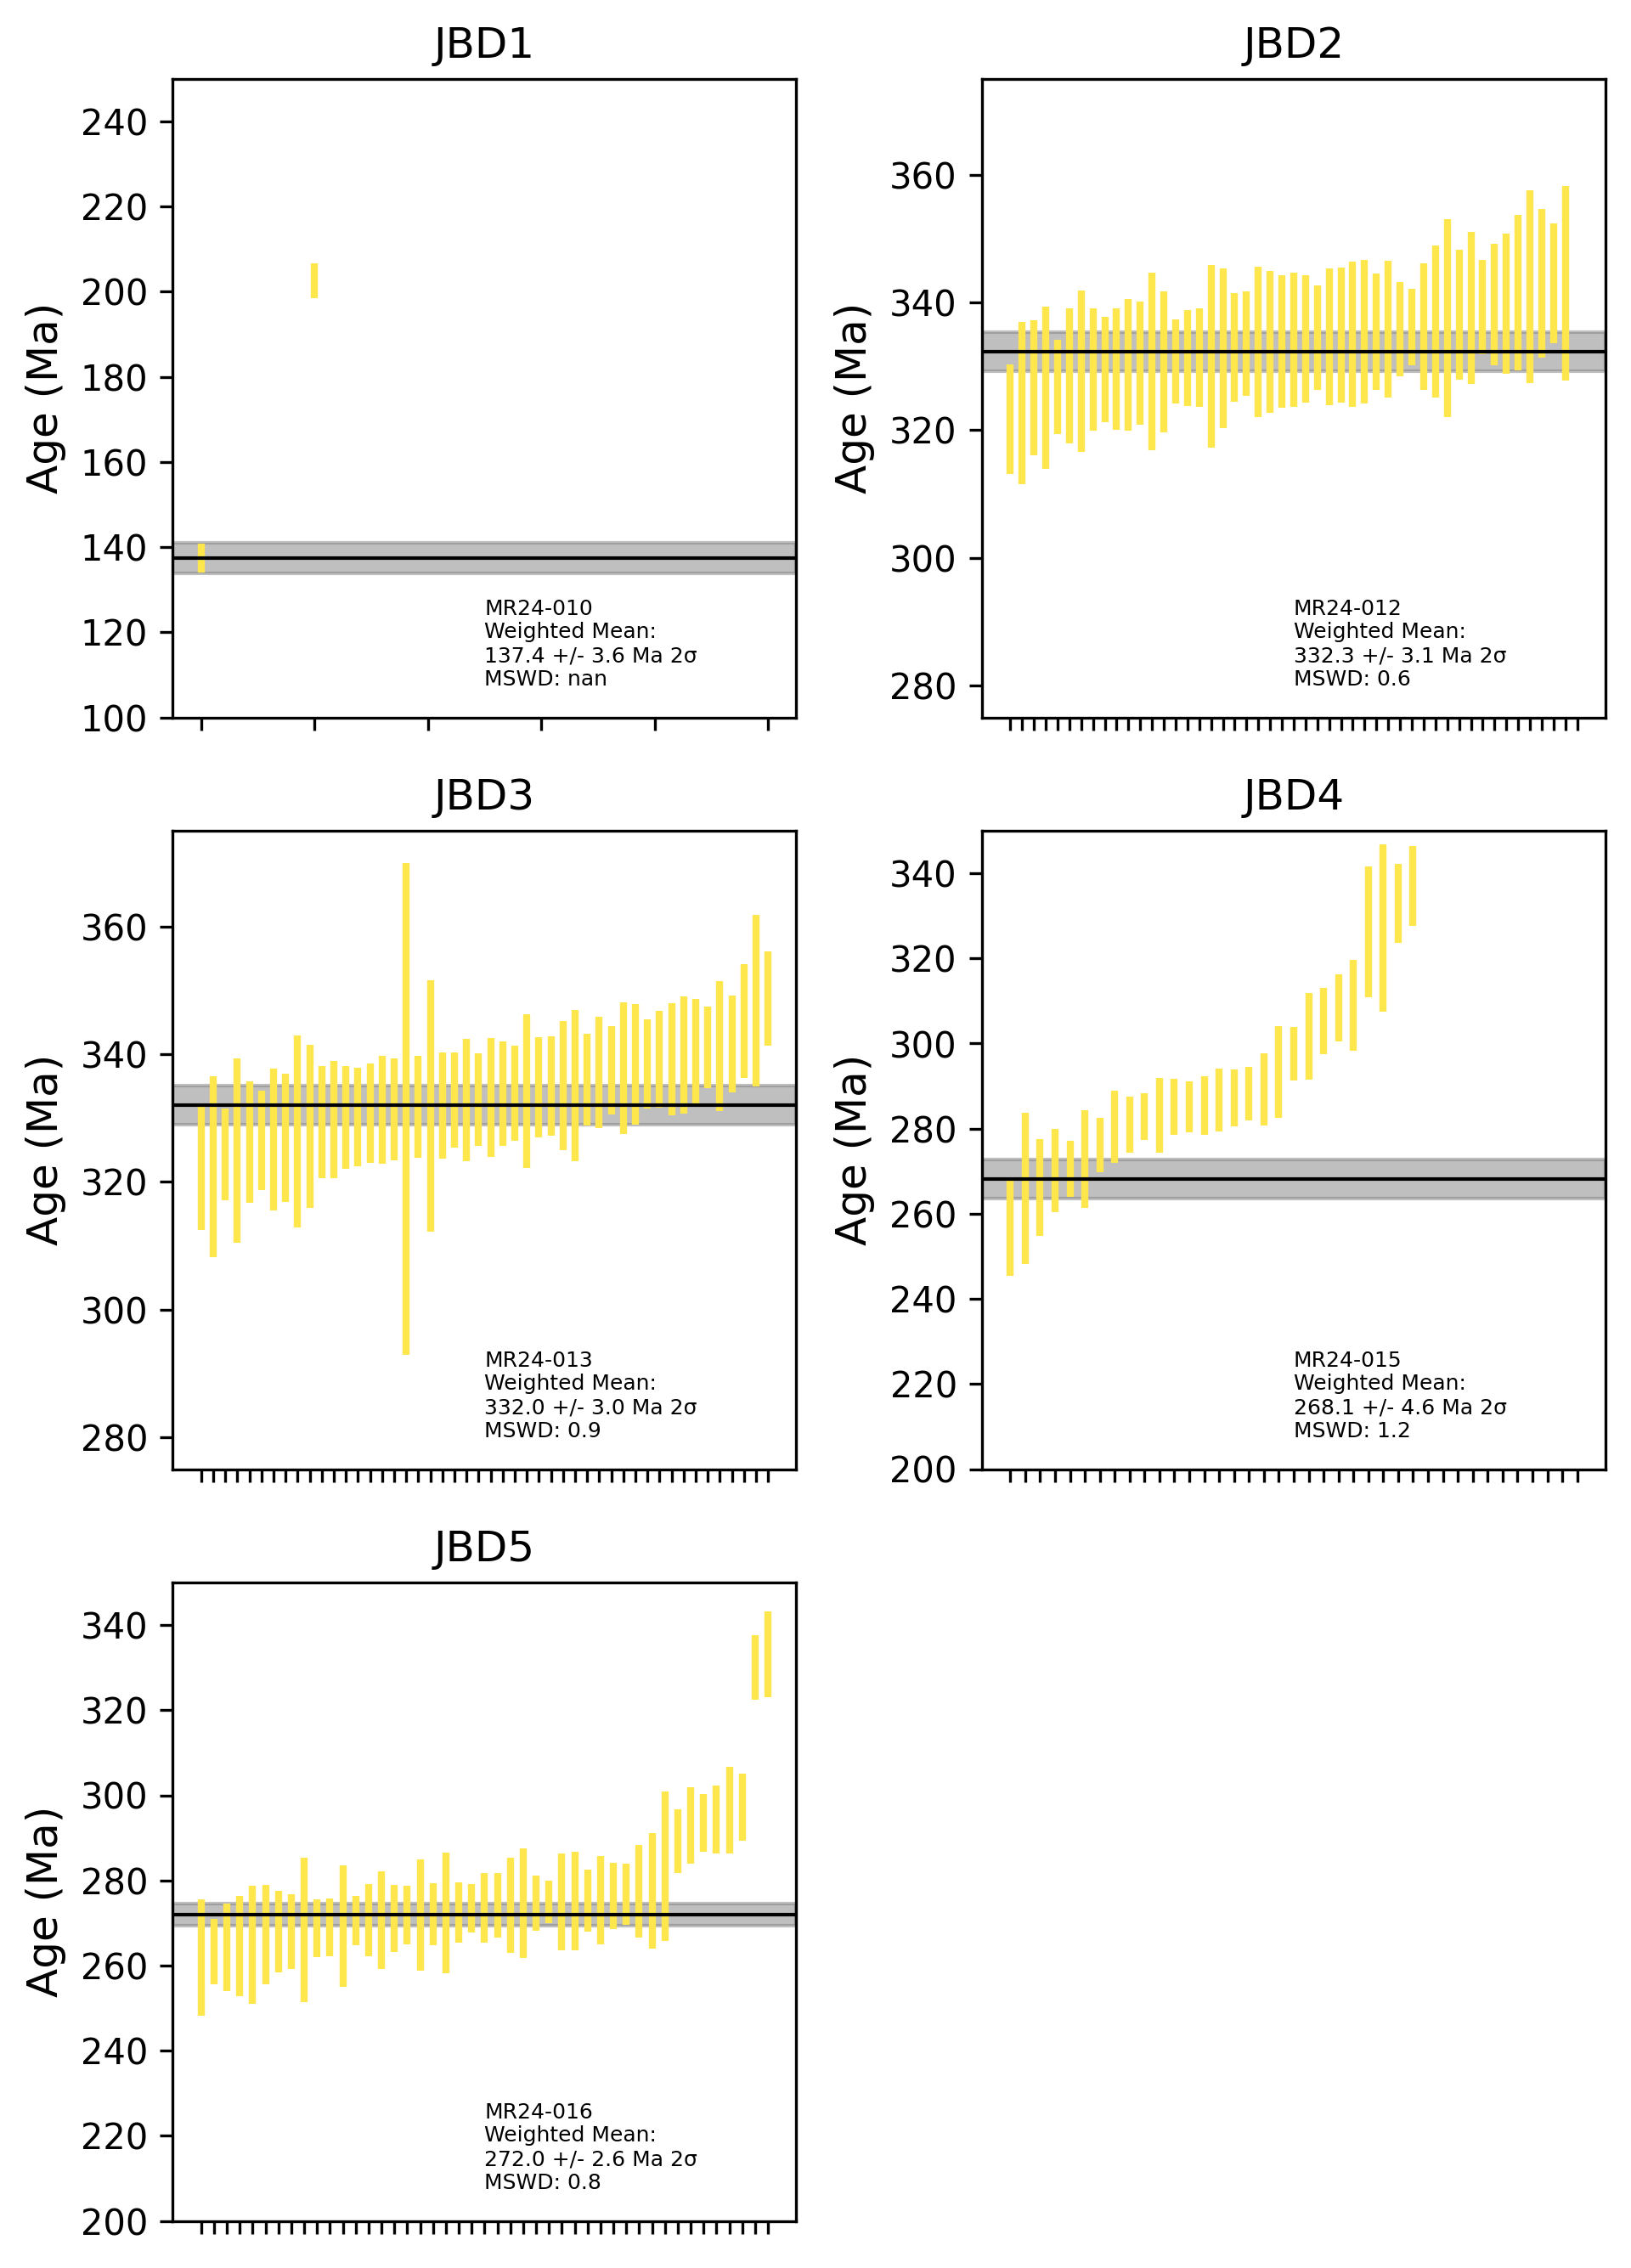

In [28]:
# Make a weighted mean plot showing all ages
fig,axs = plt.subplots(3,2,figsize=(6.5,9),dpi=300)
new_names = ['JBD1','JBD2','JBD3','JBD4','JBD5']
lim_dict = {'JBD1':(100,250),'JBD2':(275,375),'JBD3':(275,375),'JBD4':(200,350),
            'JBD5':(200,350)}

for k,ax in enumerate(axs.flat[:-1]):
    smp = smps[k]
    ax.set_title(new_names[k])

    age_df = pd.DataFrame({'Age':smp.bestage,'Error':smp.besterror})
    age_df.sort_values('Age',inplace=True)
    ax.set_ylim(lim_dict[new_names[k]])
    #ax.set_yscale('log')

    mda.plot_weighted_mean(ages=age_df['Age'], errors=age_df['Error'], mean=smp.mda, 
                           mean_error=smp.mda_err, mswd=smp.mda_mswd, ax=ax,
                           err_linewidth=2,annotate_location=(0.5,0.05),
                           color='#FDE74C', label=smp.name)

axs.flat[-1].axis('off')
plt.tight_layout()
fig.savefig('ig_means.pdf')


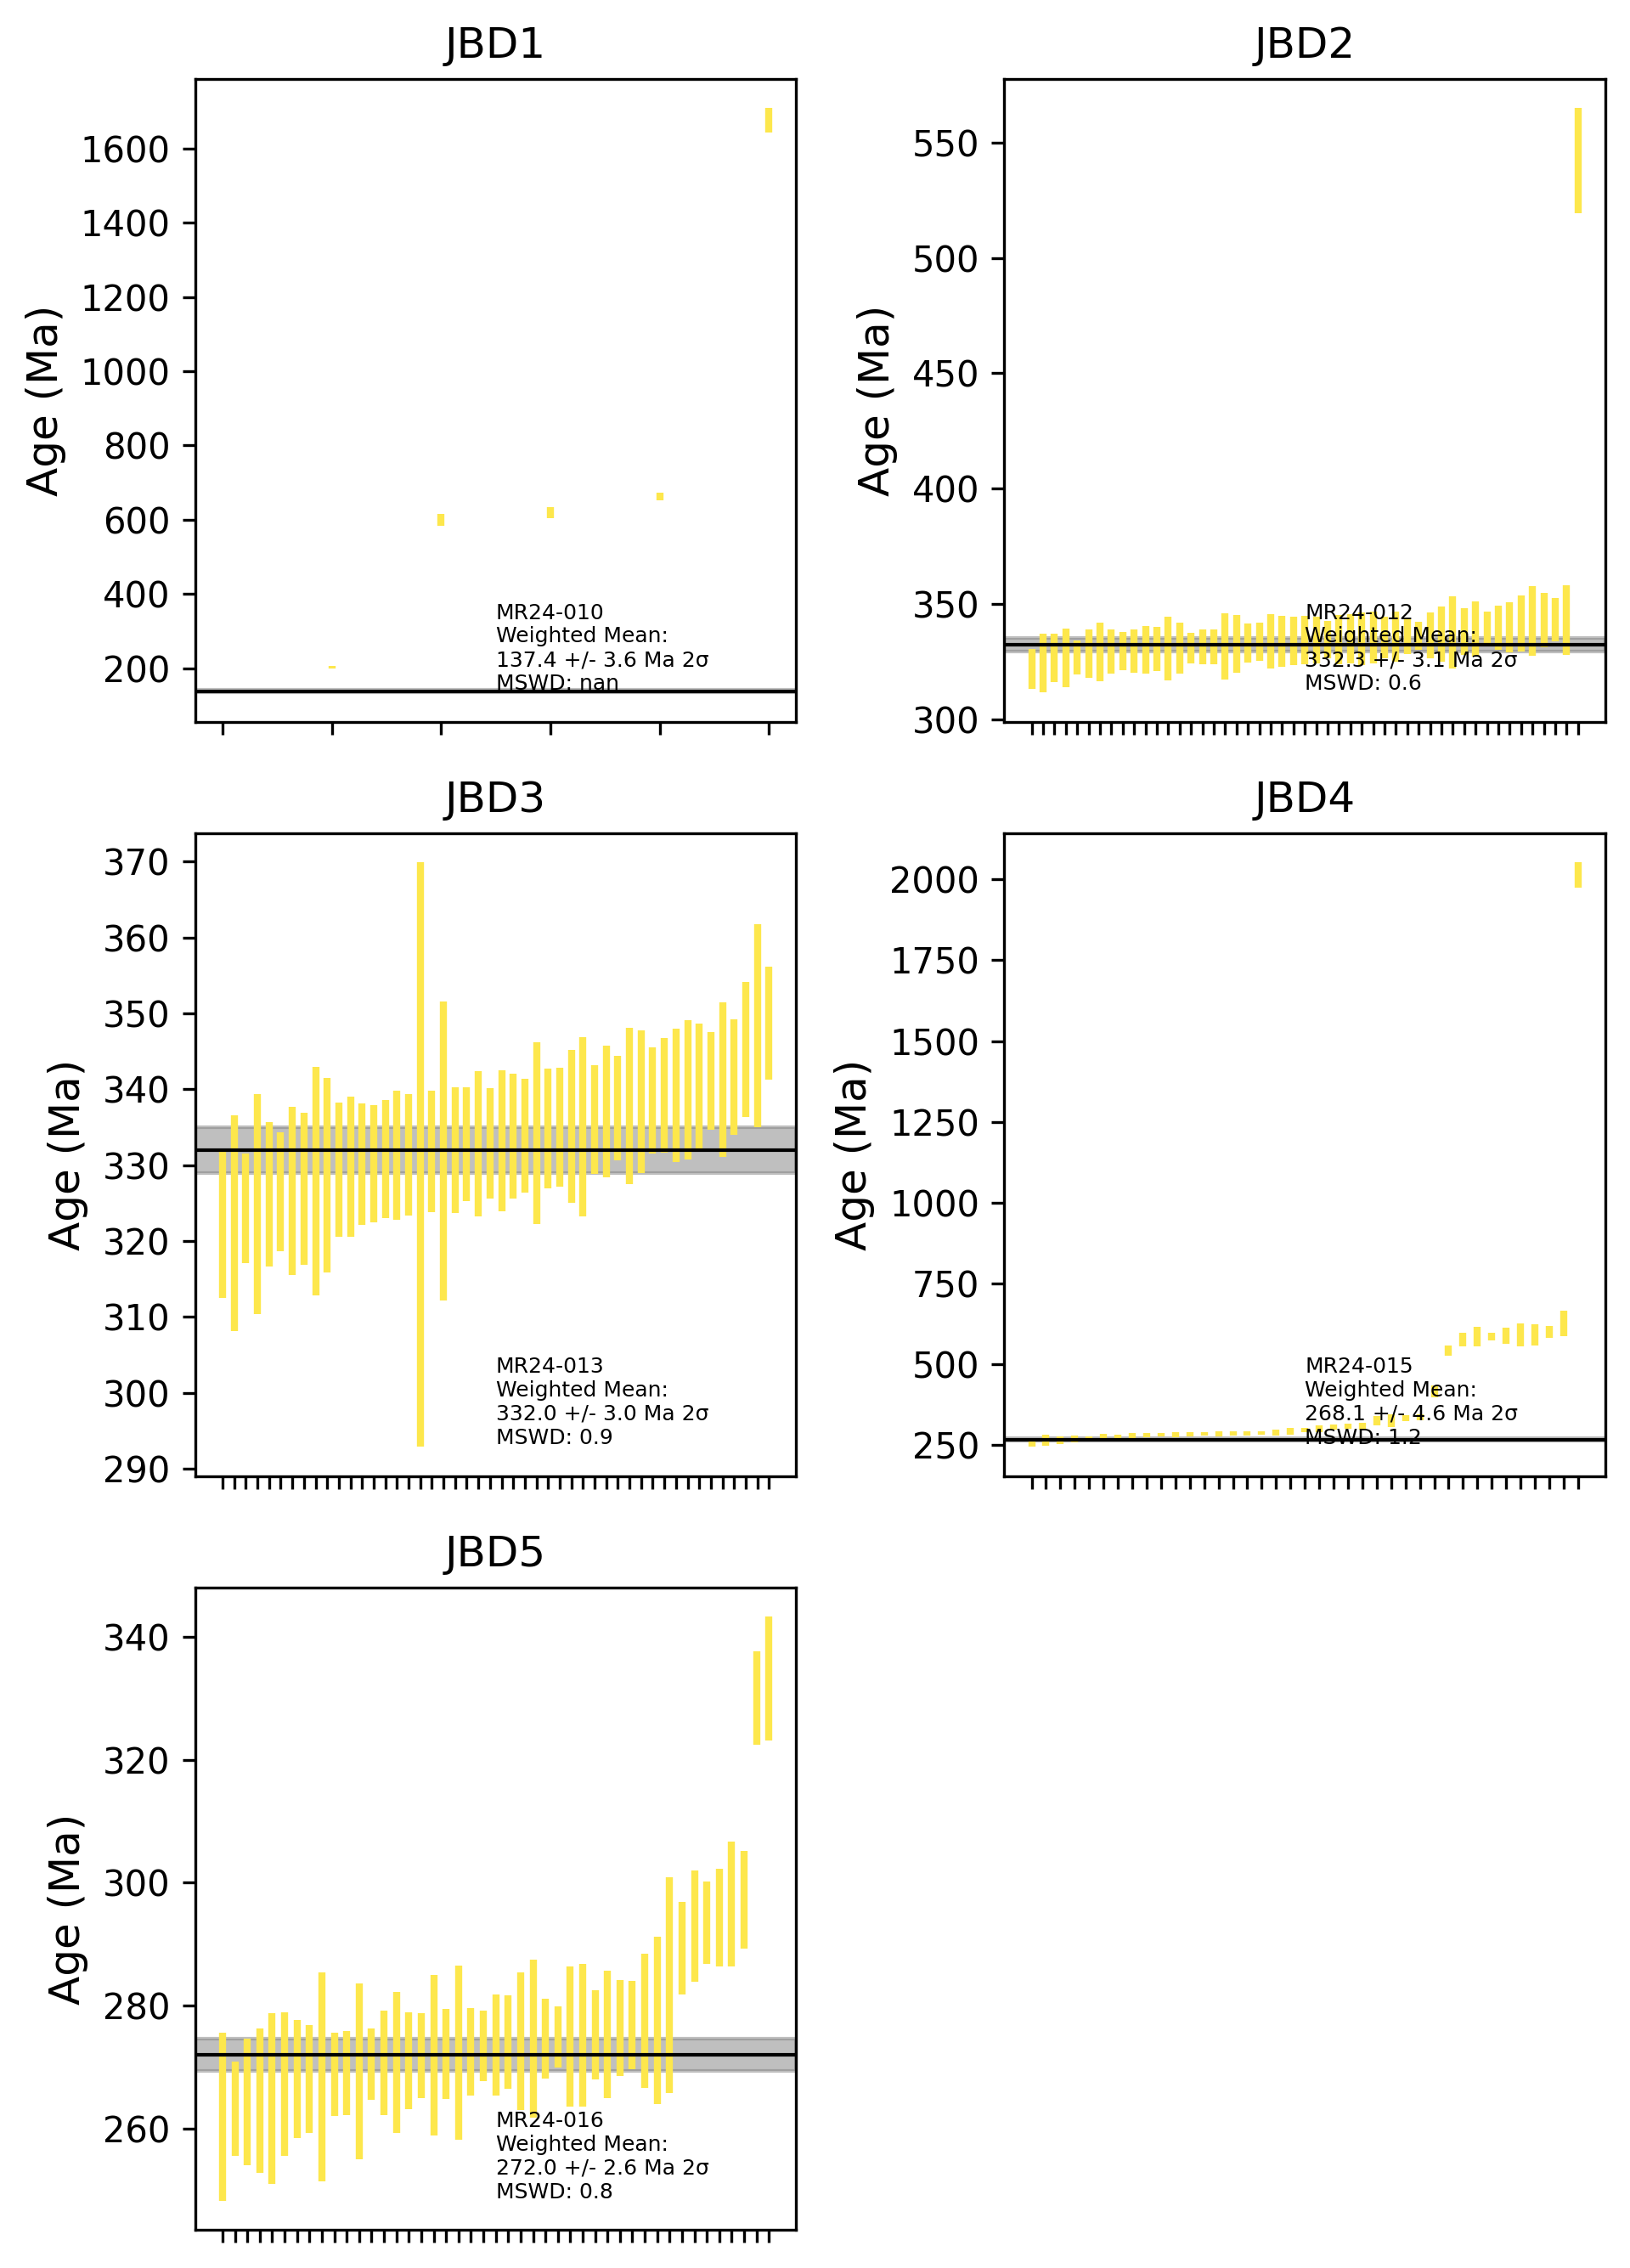

In [29]:
# Alternative version with no Y-axis cutoffs.
fig,axs = plt.subplots(3,2,figsize=(6.5,9),dpi=300)
new_names = ['JBD1','JBD2','JBD3','JBD4','JBD5']

for k,ax in enumerate(axs.flat[:-1]):
    smp = smps[k]
    ax.set_title(new_names[k])

    age_df = pd.DataFrame({'Age':smp.bestage,'Error':smp.besterror})
    age_df.sort_values('Age',inplace=True)

    mda.plot_weighted_mean(ages=age_df['Age'], errors=age_df['Error'], mean=smp.mda, 
                           mean_error=smp.mda_err, mswd=smp.mda_mswd, ax=ax,
                           err_linewidth=2,annotate_location=(0.5,0.05),
                           color='#FDE74C', label=smp.name)

axs.flat[-1].axis('off')
plt.tight_layout()
fig.savefig('ig_means_alt.pdf')